# Coverage and Capacity Optimization

## Goal

The primary goal for CCO is to **analyze and optimize the radio coverage and capacity of a cellular network** using digital twin simulations and advanced coverage metrics. Specifically, we aim to:

- **Identify and quantify areas of weak coverage and over coverage** for user equipment (UE) based on real or simulated measurement data.
- **Compute and visualize the Coverage and Capacity Optimization (CCO) metric** to assess network performance.
- **Optimize network parameters** (such as cell configuration, handover thresholds, etc.) to minimize weak and over coverage, thereby improving overall network utility.
- **Demonstrate improvements through clear visualizations** and quantitative metrics, enabling data-driven decisions for network planning and optimization.

In [26]:
import sys
import os
from typing import Dict
from pathlib import Path
import pandas as pd
sys.path.append(f"{Path().absolute().parent}")

from radp.client.client import RADPClient  # noqa: E402
from radp.client.helper import ModelStatus, RADPHelper  # noqa: E402
from apps.coverage_capacity_optimization.dgpco_cco import DgpcoCCO  # noqa: E402

### 1. Data Preparation

In [17]:
# Set input files
data_path = "/Users/tanzimfarhan/Desktop/Maveric/maveric/apps/coverage_capacity_optimization/data" # TODO: Change the path to the specific data folder
TOPOLOGY_FILE = os.path.join(data_path, "topology.csv")
TRAINING_DATA_FILES = [os.path.join(data_path, "ue_training_data.csv")]
PREDICTION_DATA_FILES = [os.path.join(data_path, "ue_data.csv")]
PREDICTION_CONFIG = os.path.join(data_path, "config.csv")
MODEL_ID = "cco_test_model"
TRAINING_PARAMS: Dict = {}

In [18]:
# Load input data
topology = pd.read_csv(TOPOLOGY_FILE)
training_data = pd.concat([pd.read_csv(file) for file in TRAINING_DATA_FILES])

In [23]:
prediction_data = pd.concat([pd.read_csv(file) for file in PREDICTION_DATA_FILES])
prediction_config = pd.read_csv(PREDICTION_CONFIG)

### 2. Run RF Digital Twin Simulation

In [21]:
# instantiate RADP client
radp_client = RADPClient()
radp_helper = RADPHelper(radp_client)

In [22]:
""" ----- TRAINING A DIGITAL TWIN ----- """
# call train API
train_response = radp_client.train(
    model_id=MODEL_ID,
    params=TRAINING_PARAMS,
    ue_training_data=training_data,
    topology=topology,
)

### 3. Compute Coverage Metrics

In [27]:
""" ----- RUNNING DGPCO CCO ALGORITHM ----- """
# set the valid config values
VALID_CONFIGURATION_VALUES = {
    "cell_el_deg": [
        0.0,
        1.0,
        2.0,
        3.0,
        4.0,
        5.0,
        6.0,
        7.0,
        8.0,
        9.0,
        10.0,
        11.0,
        12.0,
        13.0,
        14.0,
        15.0,
        16.0,
        17.0,
        18.0,
        19.0,
        20.0,
    ]
}

# instantiate the dGPCO CCO class
dgpco_cco = DgpcoCCO(
    topology=topology,
    valid_configuration_values=VALID_CONFIGURATION_VALUES,
    bayesian_digital_twin_id=MODEL_ID,
    ue_data=prediction_data,
    config=prediction_config,
)

# run the dGPCO CCO algorithm
(
    rf_dataframe_per_epoch,
    coverage_dataframe_per_epoch,
    cco_objective_per_epoch,
    opt_per_epoch,
) = dgpco_cco.run(num_epochs=5)

       cell_id  rxpower_dbm        lon        lat  mock_ue_id  tick
0     cell_1_0   -73.650857 -73.979515  40.721114           1     1
1     cell_1_0  -107.721100 -73.877470  40.740563           2     1
2     cell_1_0  -107.177636 -73.889837  40.760816           3     1
3   cell_1_120   -83.794367 -73.979515  40.721114           1     1
4   cell_1_120  -105.052415 -73.877470  40.740563           2     1
5   cell_1_120  -105.374543 -73.889837  40.760816           3     1
6   cell_1_240   -89.702279 -73.979515  40.721114           1     1
7   cell_1_240  -103.398534 -73.877470  40.740563           2     1
8   cell_1_240  -103.472960 -73.889837  40.760816           3     1
9     cell_2_0  -102.197761 -73.979515  40.721114           1     1
10    cell_2_0   -90.666457 -73.877470  40.740563           2     1
11    cell_2_0   -83.643953 -73.889837  40.760816           3     1
12  cell_2_120  -102.393989 -73.979515  40.721114           1     1
13  cell_2_120   -81.977356 -73.877470  40.74056

/Users/tanzimfarhan/Desktop/Maveric/maveric/apps/coverage_capacity_optimization/dgpco_cco.py:222: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.config.iloc[cell_config_index].cell_el_deg = best_el


       cell_id  rxpower_dbm        lon        lat  mock_ue_id  tick
0     cell_1_0   -71.657429 -73.979515  40.721114           1     1
1     cell_1_0  -105.286024 -73.877470  40.740563           2     1
2     cell_1_0  -104.697410 -73.889837  40.760816           3     1
3   cell_1_120   -83.794367 -73.979515  40.721114           1     1
4   cell_1_120  -105.052415 -73.877470  40.740563           2     1
5   cell_1_120  -105.374543 -73.889837  40.760816           3     1
6   cell_1_240   -89.702279 -73.979515  40.721114           1     1
7   cell_1_240  -103.398534 -73.877470  40.740563           2     1
8   cell_1_240  -103.472960 -73.889837  40.760816           3     1
9     cell_2_0  -102.197761 -73.979515  40.721114           1     1
10    cell_2_0   -90.666457 -73.877470  40.740563           2     1
11    cell_2_0   -83.643953 -73.889837  40.760816           3     1
12  cell_2_120  -102.393989 -73.979515  40.721114           1     1
13  cell_2_120   -81.977356 -73.877470  40.74056

/Users/tanzimfarhan/Desktop/Maveric/maveric/apps/coverage_capacity_optimization/dgpco_cco.py:222: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.config.iloc[cell_config_index].cell_el_deg = best_el


       cell_id  rxpower_dbm        lon        lat  mock_ue_id  tick
0     cell_1_0   -71.657429 -73.979515  40.721114           1     1
1     cell_1_0  -105.286024 -73.877470  40.740563           2     1
2     cell_1_0  -104.697410 -73.889837  40.760816           3     1
3   cell_1_120   -85.061234 -73.979515  40.721114           1     1
4   cell_1_120  -107.355621 -73.877470  40.740563           2     1
5   cell_1_120  -107.656949 -73.889837  40.760816           3     1
6   cell_1_240   -89.702279 -73.979515  40.721114           1     1
7   cell_1_240  -103.398534 -73.877470  40.740563           2     1
8   cell_1_240  -103.472960 -73.889837  40.760816           3     1
9     cell_2_0  -102.197761 -73.979515  40.721114           1     1
10    cell_2_0   -90.666457 -73.877470  40.740563           2     1
11    cell_2_0   -83.643953 -73.889837  40.760816           3     1
12  cell_2_120  -102.393989 -73.979515  40.721114           1     1
13  cell_2_120   -81.977356 -73.877470  40.74056

/Users/tanzimfarhan/Desktop/Maveric/maveric/apps/coverage_capacity_optimization/dgpco_cco.py:222: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.config.iloc[cell_config_index].cell_el_deg = best_el


       cell_id  rxpower_dbm        lon        lat  mock_ue_id  tick
0     cell_1_0   -71.657429 -73.979515  40.721114           1     1
1     cell_1_0  -105.286024 -73.877470  40.740563           2     1
2     cell_1_0  -104.697410 -73.889837  40.760816           3     1
3   cell_1_120   -85.061234 -73.979515  40.721114           1     1
4   cell_1_120  -107.355621 -73.877470  40.740563           2     1
5   cell_1_120  -107.656949 -73.889837  40.760816           3     1
6   cell_1_240   -90.558572 -73.979515  40.721114           1     1
7   cell_1_240  -106.155850 -73.877470  40.740563           2     1
8   cell_1_240  -106.278183 -73.889837  40.760816           3     1
9     cell_2_0  -102.197761 -73.979515  40.721114           1     1
10    cell_2_0   -90.666457 -73.877470  40.740563           2     1
11    cell_2_0   -83.643953 -73.889837  40.760816           3     1
12  cell_2_120  -102.393989 -73.979515  40.721114           1     1
13  cell_2_120   -81.977356 -73.877470  40.74056

/Users/tanzimfarhan/Desktop/Maveric/maveric/apps/coverage_capacity_optimization/dgpco_cco.py:222: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.config.iloc[cell_config_index].cell_el_deg = best_el


       cell_id  rxpower_dbm        lon        lat  mock_ue_id  tick
0     cell_1_0   -71.657429 -73.979515  40.721114           1     1
1     cell_1_0  -105.286024 -73.877470  40.740563           2     1
2     cell_1_0  -104.697410 -73.889837  40.760816           3     1
3   cell_1_120   -85.061234 -73.979515  40.721114           1     1
4   cell_1_120  -107.355621 -73.877470  40.740563           2     1
5   cell_1_120  -107.656949 -73.889837  40.760816           3     1
6   cell_1_240   -90.558572 -73.979515  40.721114           1     1
7   cell_1_240  -106.155850 -73.877470  40.740563           2     1
8   cell_1_240  -106.278183 -73.889837  40.760816           3     1
9     cell_2_0  -100.475016 -73.979515  40.721114           1     1
10    cell_2_0   -90.666919 -73.877470  40.740563           2     1
11    cell_2_0   -83.810776 -73.889837  40.760816           3     1
12  cell_2_120  -102.393989 -73.979515  40.721114           1     1
13  cell_2_120   -81.977356 -73.877470  40.74056

/Users/tanzimfarhan/Desktop/Maveric/maveric/apps/coverage_capacity_optimization/dgpco_cco.py:222: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.config.iloc[cell_config_index].cell_el_deg = best_el


### 5. Visualization

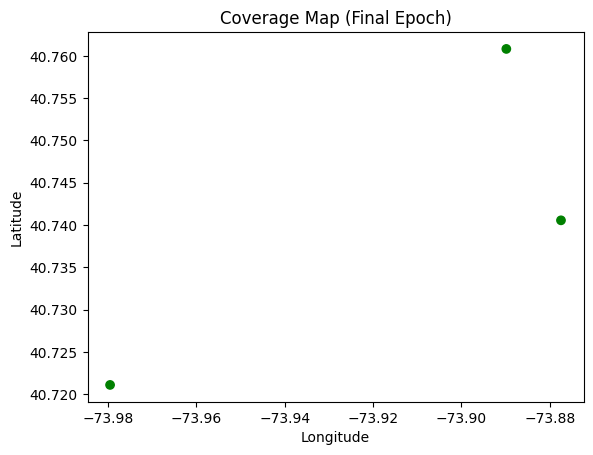

In [28]:
import matplotlib.pyplot as plt

# Pick an epoch, e.g., final epoch
df = coverage_dataframe_per_epoch[-1]
colors = df['weakly_covered'].map({True: 'red', False: 'green'})
plt.scatter(df['loc_x'], df['loc_y'], c=colors)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Coverage Map (Final Epoch)')
plt.show()

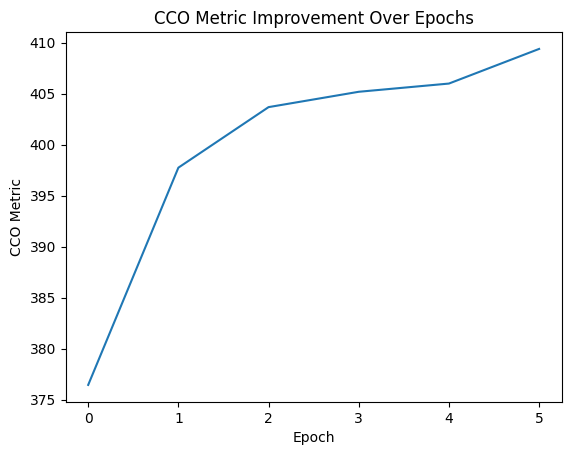

In [30]:


plt.plot(cco_objective_per_epoch)
plt.xlabel("Epoch")
plt.ylabel("CCO Metric")
plt.title("CCO Metric Improvement Over Epochs")
plt.show()

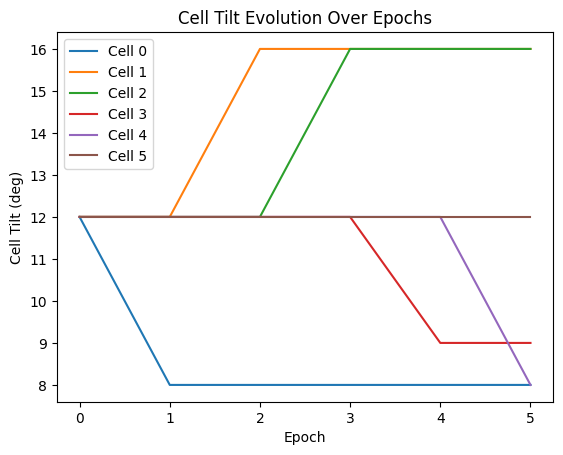

In [31]:
import numpy as np

opt_per_epoch = np.array(opt_per_epoch)  # if not already
for cell_idx in range(opt_per_epoch.shape[1]):
    plt.plot(opt_per_epoch[:, cell_idx], label=f'Cell {cell_idx}')
plt.xlabel("Epoch")
plt.ylabel("Cell Tilt (deg)")
plt.title("Cell Tilt Evolution Over Epochs")
plt.legend()
plt.show()